In [1]:
import bff
from pathlib import Path

In [9]:
qoi_dir = Path('../04-qoi').resolve()

fn_train = [
    dict(
        inputs = qoi_dir / 'qoi-train-inputs.npy',
        outputs = dict(
            rdf = qoi_dir / 'qoi-train-rdf.npy',
            hb = qoi_dir / 'qoi-train-hb.npy',
            restr = qoi_dir / 'qoi-train-restr.npy'
        ),
        outputs_ref = dict(
            rdf = qoi_dir / 'qoi-ref-rdf.npy',
            hb = qoi_dir / 'qoi-ref-hb.npy',
            restr = qoi_dir / 'qoi-ref-restr.npy'
        ),
        observations = qoi_dir / 'qoi-observations.yaml',
        nuisances = qoi_dir / 'qoi-nuisances.yaml',
        settings = qoi_dir / 'qoi-settings.yaml'
    )
]
fn_specs = qoi_dir / 'qoi-specs.yaml'

fn_hyperparams = dict(
    rdf = './hyperparams-rdf.yaml',
    hb = './hyperparams-hb.yaml',
    restr = './hyperparams-restr.yaml'
)

train_data = [bff.structures.TrainData(**files) for files in fn_train]

In [11]:
learner = bff.BFFLearn(*train_data, specs=fn_specs)
learner.setup_lgp(
    QoI=['rdf', 'hb', 'restr'],
    fn_hyper=fn_hyperparams
)
results = learner.run(max_iter=1000)

=== Bayesian Force Field Learning ===
                                                              
Optimizing LGP surrogates                                                                           
-------------------------                                                                           
> QoI: rdf                                                                                            
  - Committee: 1 (100%) | MAPE = 7.48%                                                                  
> QoI: hb                                                                                             
  - Committee: 1 (100%) | MAPE = 0.93%                                                                  
> QoI: restr                                                                                          
  - Committee: 1 (100%) | MAPE = 15.93%                                                                 
                                                                         

In [12]:
# Clean up posterior samples by discarding burn-in and thinning the chain
# if None, discard and thin are set to default values based on the autocorrelation time tau
results.prepare_samples(discard=None, thin=None)

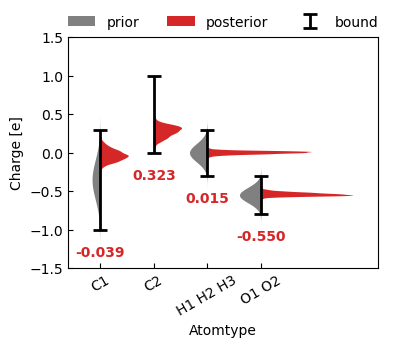

In [13]:
bff.plotting.plot_marginals(results)

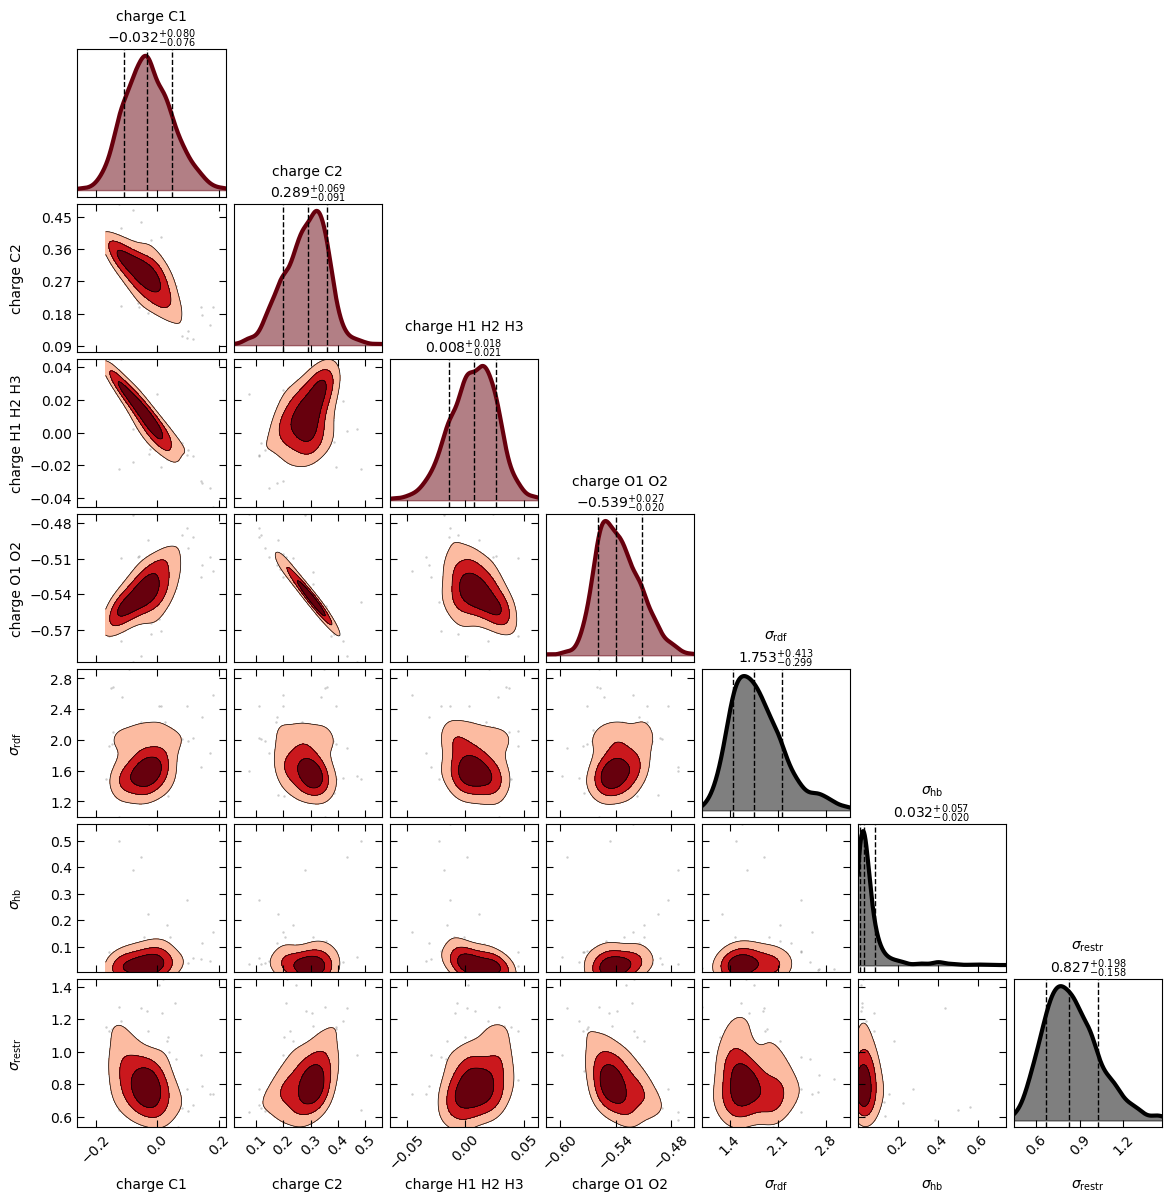

In [14]:
bff.plotting.plot_corner(results.posterior_samples, results.labels)

In [15]:
# Save posterior samples
samples = results.sample_posterior(10, fn_out='./posterior-samples.yaml')

In [16]:
# Modiy and save topology file with the first posterior sample
fn_top = Path('../01-prepare/train/topol-000.top').resolve()
top = bff.topology.TopologyModifier(
    fn_top,
    results.specs.mol_resname,
    results.specs.implicit_atoms
)

new_params = dict(zip(results.specs.bounds.names, samples[0]))
top.update_params(new_params, constraint_charge=None)
top.write('./topol-sample-001.top', overwrite=True)